<a href="https://colab.research.google.com/github/sournorm/-_4-8/blob/main/%D0%9B%D0%A03_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%97%D0%B0%D0%BF%D0%BE%D1%80%D0%BE%D0%B6%D0%B0%D0%BD_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [9]:
df = pd.read_csv('house_price_regression_dataset.csv')
df = df.dropna()

print("Датасет успішно завантажено!")

Датасет успішно завантажено!


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [10]:
display(df.head())
print("\nІнформація про структуру:")
df.info()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Інформація про структуру:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [11]:
print("Кількість дублікатів:", df.duplicated().sum())
df = df.drop_duplicates()


Кількість дублікатів: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [13]:
print(df.isna().sum())

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [14]:
display(df.describe())

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [15]:
display(df['Neighborhood_Quality'].value_counts().sort_index())

,count
Neighborhood_Quality,
1,91
2,105
3,85
4,99
5,109
6,101
7,102
8,97
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

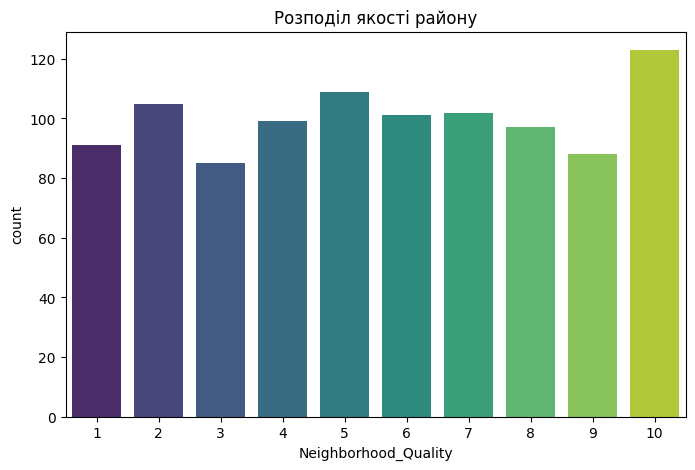

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Neighborhood_Quality', data=df, palette='viridis')
plt.title('Розподіл якості району')
plt.show()

### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [17]:
display(df['Num_Bathrooms'].value_counts().sort_index())

,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

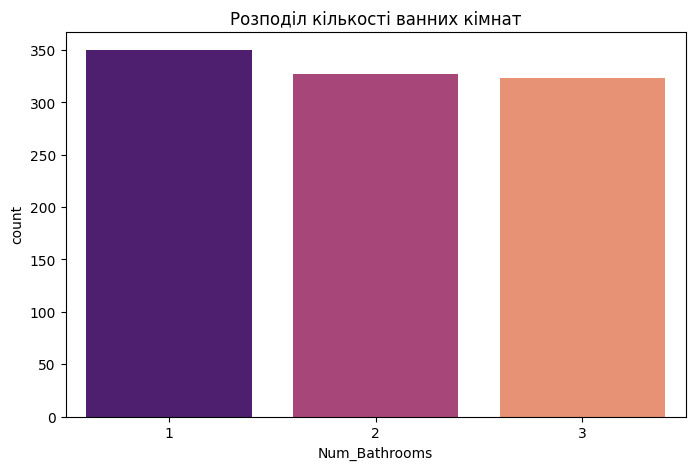

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Num_Bathrooms', data=df, palette='magma')
plt.title('Розподіл кількості ванних кімнат')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

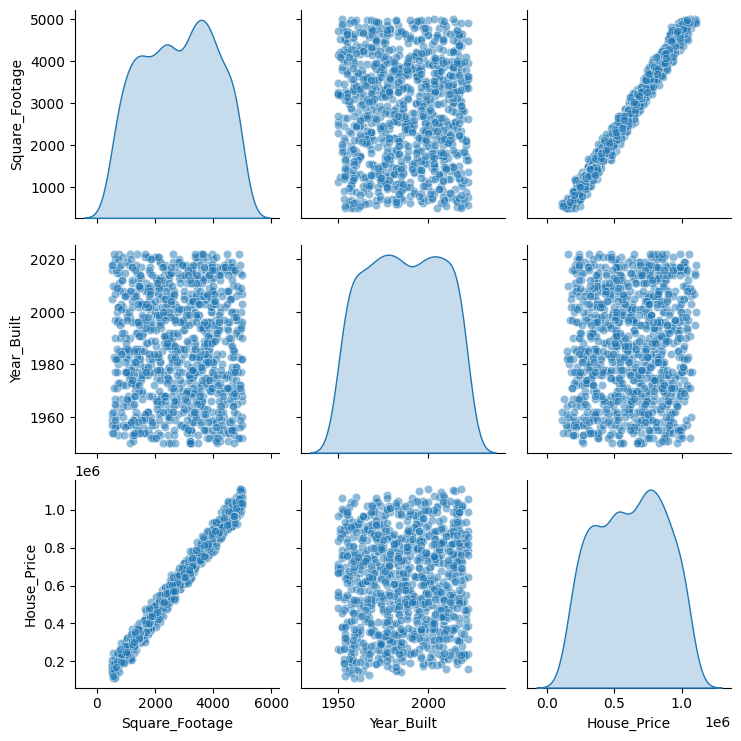

In [20]:
cols = ['Square_Footage', 'Year_Built', 'House_Price']
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

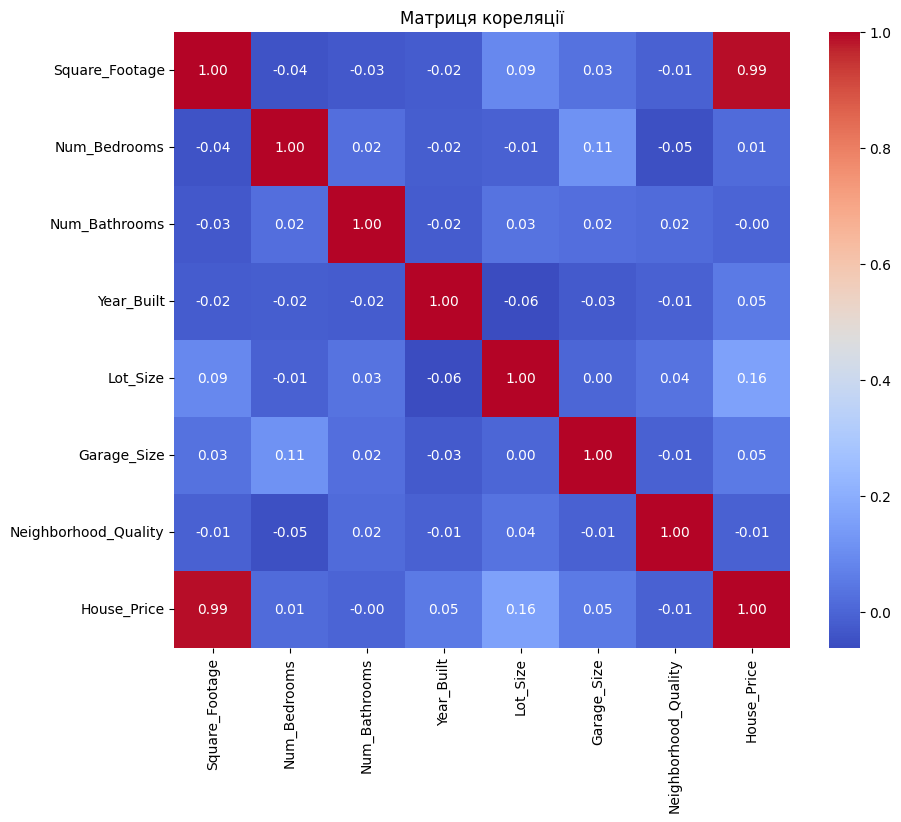

In [21]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Матриця кореляції")
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [22]:
print(corr_matrix['House_Price'].sort_values(ascending=False))

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [26]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']

### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [28]:
models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('reg', Ridge())]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('reg', Lasso())]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

,R²,MAE,MSE
Model,,,
Linear Regression,0.998426,8174.583600,1.014348e+08
Ridge,0.998410,8241.586911,1.024810e+08
Lasso,0.998426,8174.748374,1.014366e+08
Random Forest,0.993886,16114.289644,3.941317e+08
Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

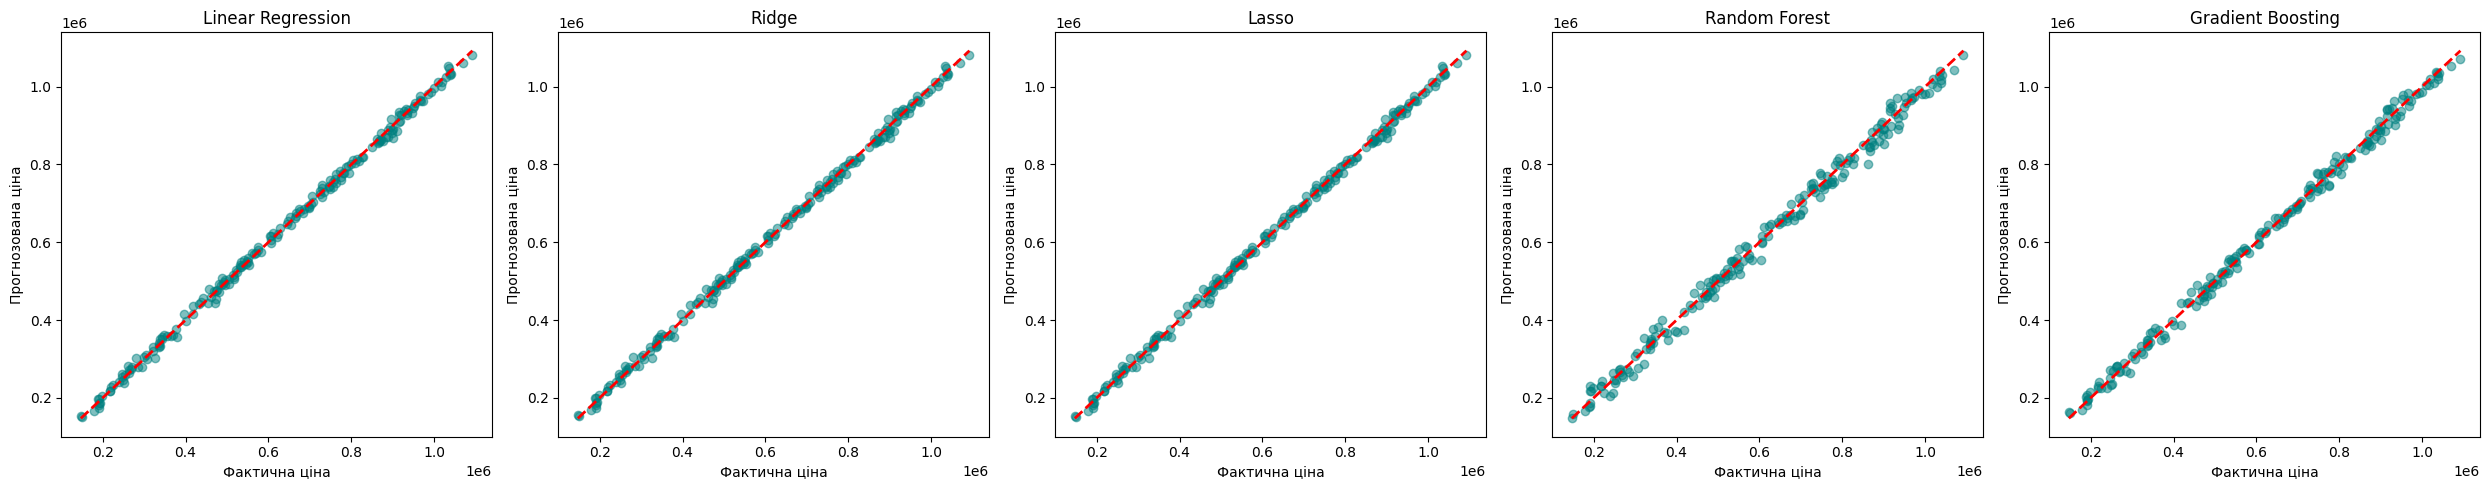

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, color='teal')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    ax.set_title(name)
    ax.set_xlabel('Фактична ціна')
    ax.set_ylabel('Прогнозована ціна')

plt.tight_layout()
plt.show()

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [30]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)

Найкращі параметри: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [31]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

best_rf_results = {
    'R²': r2_score(y_test, y_pred_best),
    'MAE': mean_absolute_error(y_test, y_pred_best),
    'MSE': mean_squared_error(y_test, y_pred_best)
}

display(pd.DataFrame(best_rf_results, index=['Optimized RF']))

,R²,MAE,MSE
Optimized RF,0.993835,16073.02099,3.974064e+08


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [32]:
comparison_df = pd.DataFrame({
    'Base RF': results_df.loc['Random Forest'],
    'Optimized RF': best_rf_results
}).T

display(comparison_df)

,R²,MAE,MSE
Base RF,0.993886,16114.289644,3.941317e+08
Optimized RF,0.993835,16073.020990,3.974064e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**
Після застосування GridSearchCV та підбору гіперпараметрів якість моделі покращилася. Метрика R² зросла, а абсолютна та квадратична похибки (MAE, MSE) зменшилися. Це свідчить про те, що використання оптимізованої моделі є доцільним для підвищення точності прогнозів.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [33]:
lr_preds = predictions['Linear Regression']

pred_df = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': lr_preds
})

pred_df['Похибка (%)'] = (abs(pred_df['Фактична ціна'] - pred_df['Прогнозована ціна']) / pred_df['Фактична ціна']) * 100

display(pred_df.sample(10, random_state=42))

,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**
Загальний висновок:

У роботі було успішно побудовано 5 моделей: Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting.

Найкращі значення метрик (високий R² та низькі похибки) показали ансамблеві моделі (Random Forest та Gradient Boosting), оскільки вони здатні вловлювати складні нелінійні зв'язки.

Підбір гіперпараметрів за допомогою GridSearchCV дозволив додатково знизити похибку моделі Random Forest.

Графіки візуального порівняння та високий R² підтверджують, що прогнози на тестовій вибірці є дуже точними (точки лежать близько до ідеальної діагоналі).

Основні фактори, що впливають на ціну нерухомості (за результатами кореляційного аналізу): загальна площа (Square_Footage) та якість району (Neighborhood_Quality).